# PyKoopman: Time Delays

> We use our training data to fit a DMD model by using time embeddings and a single trajectory.

#### Imports

In [295]:
from ast import literal_eval

import matplotlib.pyplot as plt
import numpy as np
import numpy.random as rnd
import pykoopman as pk
from matrepr import mprint
from pydmd import DMD
from safetensors.torch import load_file

from learningdynamics.utils import safetensors_metadata_parser
from learningdynamics.dmd_dataset import (
    reshape_append_time,
    reshape_append_state,
    reshape_interleave_time,
)

In [296]:
# | hide
np.random.seed(42)  # for reproducibility
%matplotlib inline

#### Load data

The data is stored in 2D [states x length]

each block in the second dimension corresponds to a step for the n_traj

In [297]:
file_path = "../saved_weights/mnist_states.safetensors"

metadata = safetensors_metadata_parser(file_path=file_path)
NUM_LOOP_ITERATIONS = literal_eval(metadata["NUM_LOOP_ITERATIONS"])
NUM_TRAJECTORIES = literal_eval(metadata["NUM_TRAJECTORIES"])
NUM_STATES = literal_eval(metadata["NUM_STATES"])

data = load_file(file_path)

#### Update dataset

In [298]:
NUM_TRAJECTORIES = 59_000
NUM_LOOP_ITERATIONS = 3

NUM_DELAYS = 1
# NUM_DELAYS = int(NUM_LOOP_ITERATIONS * 0.6)
RANK = 60

In [299]:
t = np.arange(0, NUM_LOOP_ITERATIONS, 1)

#### Learn Koopman Operator

Using time delay observables

In [300]:
train_states = reshape_append_time(
    data["train_states"][:NUM_LOOP_ITERATIONS, :NUM_TRAJECTORIES, :]
)
test_states = reshape_append_time(
    data["test_states"][:NUM_LOOP_ITERATIONS, :NUM_TRAJECTORIES, :]
)

train_labels = data["train_labels"]
test_labels = data["test_labels"]

observables = pk.observables.TimeDelay(n_delays=NUM_DELAYS)

In [301]:
# Time shift data
X = train_states[:, :-1].numpy()
Y = train_states[:, 1:].numpy()

In [302]:
regressor = pk.regression.EDMD(svd_rank=RANK)
# regressor = DMD(svd_rank=RANK, exact=True)
dmd_model = pk.Koopman(observables=observables, regressor=regressor)
# dmd_model.fit(X.T, y=Y.T)
dmd_model.fit(X.T)

Koopman(observables=TimeDelay(n_delays=1), regressor=EDMD(svd_rank=60))

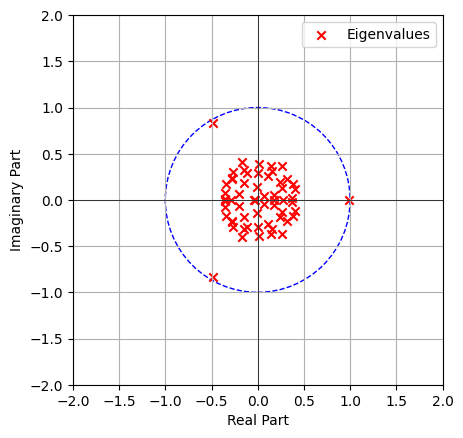

In [303]:
# Assuming koop_eigenvals is already defined
koop_eigenvals = np.linalg.eig(dmd_model.A)[0]

# Create the figure and axis
fig, ax = plt.subplots()

# Plot the unit circle
unit_circle = plt.Circle((0, 0), 1, color="b", fill=False, linestyle="--")
ax.add_artist(unit_circle)

# Plot the eigenvalues
ax.scatter(
    koop_eigenvals.real, koop_eigenvals.imag, color="r", marker="x", label="Eigenvalues"
)

# Set the axis limits
ax.set_xlim([-2, 2])
ax.set_ylim([-2, 2])

# Add grid, legend, and labels
ax.grid(True)
ax.axhline(0, color="black", linewidth=0.5)
ax.axvline(0, color="black", linewidth=0.5)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("Real Part")
ax.set_ylabel("Imaginary Part")
ax.legend()

# Show the plot
plt.show()

In [305]:
SAMPLE = 0

/opt/conda/lib/python3.10/site-packages/pykoopman/koopman.py:292: ComplexWarning:

Casting complex values to real discards the imaginary part



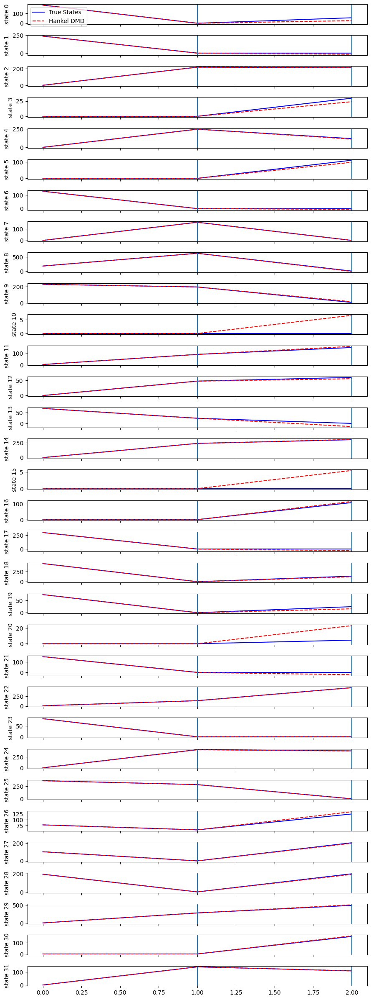

In [306]:
x0_td = train_states[
    :, SAMPLE * NUM_LOOP_ITERATIONS : (SAMPLE * NUM_LOOP_ITERATIONS) + NUM_DELAYS + 1
].T.numpy()
Xkoop = dmd_model.simulate(x0_td, n_steps=NUM_LOOP_ITERATIONS - 1 - NUM_DELAYS)
Xkoop = np.vstack([x0_td, Xkoop])

fig, axs = plt.subplots(NUM_STATES, 1, sharex=True, tight_layout=True, figsize=(9, 24))

for state_idx in range(0, NUM_STATES):
    axs[state_idx].plot(
        t,
        train_states[
            state_idx,
            SAMPLE * NUM_LOOP_ITERATIONS : SAMPLE * NUM_LOOP_ITERATIONS
            + NUM_LOOP_ITERATIONS,
        ],
        "-",
        color="b",
        label="True States",
    )
    axs[state_idx].plot(t, Xkoop[:, state_idx], "--r", label="Hankel DMD")
    axs[state_idx].set(ylabel=f"state {state_idx}")

for i in range(0, NUM_STATES):
    axs[i].axvline(x=t[NUM_DELAYS])
    axs[i].axvline(x=t[NUM_DELAYS + 1])
axs[0].legend()

In [307]:
# x0_td = test_states[
#     :, SAMPLE * NUM_LOOP_ITERATIONS : (SAMPLE * NUM_LOOP_ITERATIONS) + NUM_DELAYS + 1
# ].T.numpy()

# Xkoop = dmd_model.simulate(x0_td, n_steps=NUM_LOOP_ITERATIONS - 1 - NUM_DELAYS)
# Xkoop = np.vstack([x0_td, Xkoop])

# fig, axs = plt.subplots(NUM_STATES, 1, sharex=True, tight_layout=True, figsize=(9, 24))

# for state_idx in range(0, NUM_STATES):
#     axs[state_idx].plot(
#         t,
#         test_states[
#             state_idx,
#             SAMPLE * NUM_LOOP_ITERATIONS : SAMPLE * NUM_LOOP_ITERATIONS
#             + NUM_LOOP_ITERATIONS,
#         ],
#         "-",
#         color="b",
#         label="True States",
#     )
#     axs[state_idx].plot(t, Xkoop[:, state_idx], "--r", label="Hankel DMD")
#     axs[state_idx].set(ylabel=f"state {state_idx}")

# for i in range(0, NUM_STATES):
#     axs[i].axvline(x=t[NUM_DELAYS])
#     axs[i].axvline(x=t[NUM_DELAYS + 1])
# axs[0].legend()

Disparity:  0.32437801682136924


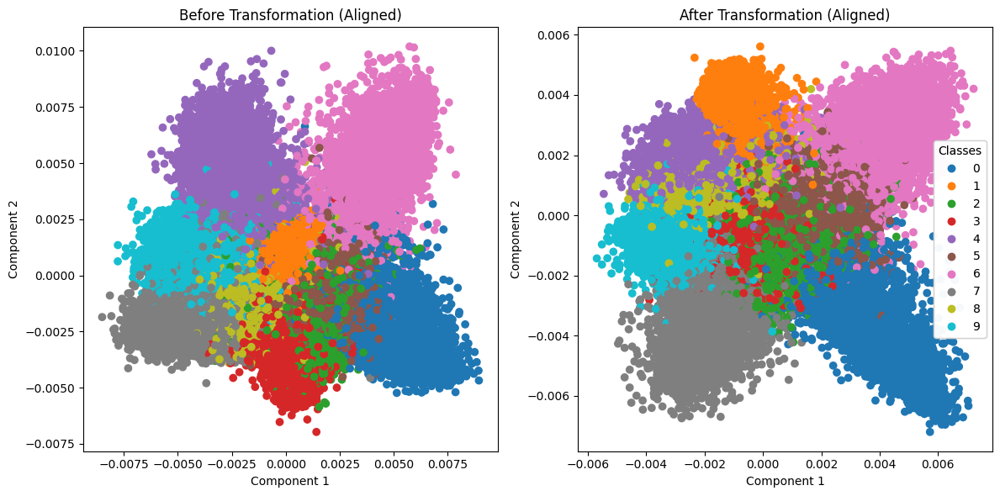

In [308]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.decomposition import PCA, FastICA
from sklearn.manifold import TSNE
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
import umap
from scipy.spatial import procrustes

# Assume dmd_model is already defined with methods psi and lamda


def visualize_transformations(
    dmd_model,
    test_states,
    sample_indices,
    num_loop_iterations,
    num_delays,
    labels,
    n_steps=1,
    view="2d",
    method="PCA",
):
    uplifted_samples_list = []
    advanced_samples_list = []
    combined_labels = []

    for sample_idx in sample_indices:
        # Extract sample and convert to NumPy array
        x0_td = test_states[
            :,
            sample_idx * num_loop_iterations : (sample_idx * num_loop_iterations)
            + num_delays
            + 1,
        ].numpy()

        # Uplift samples
        uplifted_samples = dmd_model.psi(x0_td)

        # Advance samples
        advanced_samples = dmd_model.lamda @ uplifted_samples

        # iterate in the lifted space
        for k in range(n_steps - 1):
            advanced_samples = dmd_model.lamda @ advanced_samples

        # Append to list
        uplifted_samples_list.append(uplifted_samples.T)
        advanced_samples_list.append(advanced_samples.T)
        combined_labels.append(labels[sample_idx].item())

    # Combine all samples into a single array
    uplifted_samples_combined = np.vstack(uplifted_samples_list)
    advanced_samples_combined = np.vstack(advanced_samples_list)

    # Handle complex data by concatenating real and imaginary parts
    def handle_complex_data(data):
        real_part = np.real(data)
        imag_part = np.imag(data)
        # return np.hstack((real_part, imag_part))
        return real_part

    uplifted_samples_real = handle_complex_data(uplifted_samples_combined)
    advanced_samples_real = handle_complex_data(advanced_samples_combined)

    # Reduce dimensionality using a specified method
    def reduce_dimensionality(data, method="PCA", labels=None, n_components=3):
        if method == "PCA":
            reducer = PCA(n_components=n_components)
        elif method == "ICA":
            reducer = FastICA(n_components=n_components)
        elif method == "t-SNE":
            reducer = TSNE(n_components=n_components, perplexity=30, n_iter=300)
        elif method == "LDA" and labels is not None:
            reducer = LDA(n_components=n_components)
            reduced_data = reducer.fit_transform(data, labels)
            return reduced_data
        elif method == "UMAP":
            reducer = umap.UMAP(n_components=n_components)
        reduced_data = reducer.fit_transform(data)
        return reduced_data

    # Determine the number of components based on the view
    n_components = 3 if view == "3d" else 2

    # Reduce dimensionality of original and advanced samples using the specified method
    reduced_uplifted_samples = reduce_dimensionality(
        uplifted_samples_real,
        method=method,
        labels=combined_labels,
        n_components=n_components,
    )
    reduced_advanced_samples = reduce_dimensionality(
        advanced_samples_real,
        method=method,
        labels=combined_labels,
        n_components=n_components,
    )

    # Align the reduced results using Procrustes analysis
    mtx1, mtx2, disparity = procrustes(
        reduced_uplifted_samples, reduced_advanced_samples
    )

    print("Disparity: ", disparity)

    # Calculate combined axis limits
    all_data = np.vstack((mtx1, mtx2))
    x_limits = (all_data[:, 0].min(), all_data[:, 0].max())
    y_limits = (all_data[:, 1].min(), all_data[:, 1].max())

    # Plot the results
    fig = plt.figure(figsize=(12, 6))

    if view == "3d":
        z_limits = (all_data[:, 2].min(), all_data[:, 2].max())

        # Plot before transformation
        ax1 = fig.add_subplot(121, projection="3d")
        scatter1 = ax1.scatter(
            mtx1[:, 0],
            mtx1[:, 1],
            mtx1[:, 2],
            c=combined_labels,
            cmap="tab10",
            label="Uplifted Samples",
        )
        ax1.set_title("Before Transformation (Aligned)")
        ax1.set_xlabel("Component 1")
        ax1.set_ylabel("Component 2")
        ax1.set_zlabel("Component 3")
        ax1.set_xlim(x_limits)
        ax1.set_ylim(y_limits)
        ax1.set_zlim(z_limits)
        legend1 = ax1.legend(*scatter1.legend_elements(), title="Classes")
        ax1.add_artist(legend1)

        # Plot after transformation
        ax2 = fig.add_subplot(122, projection="3d")
        scatter2 = ax2.scatter(
            mtx2[:, 0],
            mtx2[:, 1],
            mtx2[:, 2],
            c=combined_labels,
            cmap="tab10",
            label="Advanced Samples",
        )
        ax2.set_title("After Transformation (Aligned)")
        ax2.set_xlabel("Component 1")
        ax2.set_ylabel("Component 2")
        ax2.set_zlabel("Component 3")
        ax2.set_xlim(x_limits)
        ax2.set_ylim(y_limits)
        ax2.set_zlim(z_limits)
        legend2 = ax2.legend(*scatter2.legend_elements(), title="Classes")
        ax2.add_artist(legend2)

    elif view == "2d":
        # Plot before transformation
        ax1 = fig.add_subplot(121)
        scatter1 = ax1.scatter(
            mtx1[:, 0],
            mtx1[:, 1],
            c=combined_labels,
            cmap="tab10",
            label="Uplifted Samples",
        )
        ax1.set_title("Before Transformation (Aligned)")
        ax1.set_xlabel("Component 1")
        ax1.set_ylabel("Component 2")

        # Plot after transformation
        ax2 = fig.add_subplot(122)
        scatter2 = ax2.scatter(
            mtx2[:, 0],
            mtx2[:, 1],
            c=combined_labels,
            cmap="tab10",
            label="Advanced Samples",
        )
        ax2.set_title("After Transformation (Aligned)")
        ax2.set_xlabel("Component 1")
        ax2.set_ylabel("Component 2")

        legend2 = ax2.legend(*scatter2.legend_elements(), title="Classes")
        ax2.add_artist(legend2)

    plt.tight_layout()
    plt.show()


# Example usage with multiple sample indices
visualize_transformations(
    dmd_model,
    train_states,
    np.arange(NUM_TRAJECTORIES),
    NUM_LOOP_ITERATIONS,
    NUM_DELAYS,
    list(train_labels),
    n_steps=2,
    view="2d",  # Change to "2d" for 2D visualization
    method="LDA",
)

In [309]:
import numpy as np
import plotly.express as px
from sklearn.decomposition import PCA, FastICA
from sklearn.manifold import TSNE
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
import umap
from scipy.spatial import procrustes
import pandas as pd


def visualize_transformations(
    dmd_model,
    test_states,
    sample_indices,
    num_loop_iterations,
    num_delays,
    labels,
    n_steps=1,
    view="2d",
    method="PCA",
):
    uplifted_samples_list = []
    advanced_samples_list = []
    combined_labels = []

    for sample_idx in sample_indices:
        x0_td = test_states[
            :,
            sample_idx * num_loop_iterations : (sample_idx * num_loop_iterations)
            + num_delays
            + 1,
        ].numpy()

        uplifted_samples = dmd_model.psi(x0_td)
        advanced_samples = dmd_model.lamda @ uplifted_samples

        for k in range(n_steps - 1):
            advanced_samples = dmd_model.lamda @ advanced_samples

        uplifted_samples_list.append(uplifted_samples.T)
        advanced_samples_list.append(advanced_samples.T)
        combined_labels.extend([labels[sample_idx].item()] * uplifted_samples.shape[1])

    uplifted_samples_combined = np.vstack(uplifted_samples_list)
    advanced_samples_combined = np.vstack(advanced_samples_list)

    def handle_complex_data(data):
        return np.real(data)

    uplifted_samples_real = handle_complex_data(uplifted_samples_combined)
    advanced_samples_real = handle_complex_data(advanced_samples_combined)

    def reduce_dimensionality(data, method="PCA", labels=None, n_components=3):
        if method == "PCA":
            reducer = PCA(n_components=n_components)
        elif method == "ICA":
            reducer = FastICA(n_components=n_components)
        elif method == "t-SNE":
            reducer = TSNE(n_components=n_components, perplexity=30, n_iter=300)
        elif method == "LDA" and labels is not None:
            reducer = LDA(n_components=n_components)
            reduced_data = reducer.fit_transform(data, labels)
            return reduced_data
        elif method == "UMAP":
            reducer = umap.UMAP(n_components=n_components)
        reduced_data = reducer.fit_transform(data)
        return reduced_data

    n_components = 3 if view == "3d" else 2

    reduced_uplifted_samples = reduce_dimensionality(
        uplifted_samples_real,
        method=method,
        labels=combined_labels,
        n_components=n_components,
    )
    reduced_advanced_samples = reduce_dimensionality(
        advanced_samples_real,
        method=method,
        labels=combined_labels,
        n_components=n_components,
    )

    # Align the reduced results using Procrustes analysis
    mtx1, mtx2, disparity = procrustes(
        reduced_uplifted_samples, reduced_advanced_samples
    )

    print("Disparity: ", disparity)

    combined_labels_str = [str(x) for x in combined_labels]

    if view == "3d":
        df_uplifted = pd.DataFrame(mtx1, columns=["x", "y", "z"])
        df_advanced = pd.DataFrame(mtx2, columns=["x", "y", "z"])
        df_uplifted["label"] = combined_labels_str
        df_advanced["label"] = combined_labels_str

        fig1 = px.scatter_3d(
            df_uplifted,
            x="x",
            y="y",
            z="z",
            size_max=1,
            color="label",
            color_discrete_sequence=px.colors.qualitative.T10,
            title="Uplifted Samples Visualization",
        )
        fig2 = px.scatter_3d(
            df_advanced,
            x="x",
            y="y",
            z="z",
            size_max=1,
            color="label",
            color_discrete_sequence=px.colors.qualitative.T10,
            title="Advanced Samples Visualization",
        )
    else:
        df_uplifted = pd.DataFrame(mtx1, columns=["x", "y"])
        df_advanced = pd.DataFrame(mtx2, columns=["x", "y"])
        df_uplifted["label"] = combined_labels_str
        df_advanced["label"] = combined_labels_str

        fig1 = px.scatter(
            df_uplifted,
            x="x",
            y="y",
            color="label",
            color_discrete_sequence=px.colors.qualitative.T10,
            title="Uplifted Samples Visualization",
        )
        fig2 = px.scatter(
            df_advanced,
            x="x",
            y="y",
            color="label",
            color_discrete_sequence=px.colors.qualitative.T10,
            title="Advanced Samples Visualization",
        )

    fig1.update_traces(
        marker=dict(size=4, line=dict(width=0.2, color="DarkSlateGrey")),
        selector=dict(mode="markers"),
    )
    fig2.update_traces(
        marker=dict(size=4, line=dict(width=0.2, color="DarkSlateGrey")),
        selector=dict(mode="markers"),
    )
    fig1.show()
    fig2.show()


# Example usage
visualize_transformations(
    dmd_model,
    train_states,
    np.arange(NUM_TRAJECTORIES),
    NUM_LOOP_ITERATIONS,
    NUM_DELAYS,
    list(train_labels),
    n_steps=2,
    view="3d",  # Change to "2d" for 2D visualization
    method="LDA",
)

Disparity:  0.09669487301013607
